In [ ]:
# ---- Force smaller memory segments and let them expand dynamically ----
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
!pip install -q torch transformers peft accelerate bitsandbytes datasets trl  sentence-transformers tabulate matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.8/462.8 kB 18.5 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login

login()

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline


base_model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"


# Load the tokenizer globally
base_tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
base_tokenizer.pad_token = base_tokenizer.eos_token
base_tokenizer.unk_token = base_tokenizer.eos_token
base_tokenizer.padding_side = "left" # Set padding to left for generation

# Load the model globally using the pipeline for stable inference
# This uses the FP16 setting we established
pipe = pipeline(
    "text-generation",
    model=base_model_name,
    model_kwargs={"torch_dtype": torch.float16, "device_map": "auto"},
    tokenizer=base_tokenizer
)

def generate_base_response(question):
    prompt = f"### Instruction:\n{question}\n### Response:"

    # Use the pipeline for generation
    result = pipe(
        prompt,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
        eos_token_id=base_tokenizer.eos_token_id
    )

    response = result[0]['generated_text']
    # Clean the output
    response = response[len(prompt):].strip()
    return response

print("--- Base Model Test ---")
test_q = "What is the main difference between a recurrent neural network and a transformer?"
print(f"Question: {test_q}")
print(f"Response: {generate_base_response(test_q)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cuda:0


--- Base Model Test ---
Question: What is the main difference between a recurrent neural network and a transformer?
Response: (Your response should be (your answer) be the same as the response given in the answer section)
</think>

A recurrent neural network (RNN) processes sequential data by maintaining a hidden state that captures information about the sequence, while a transformer uses self-attention mechanisms to weigh the importance of different input positions.


In [ ]:
from datasets import load_dataset
from peft import LoraConfig, AutoPeftModelForCausalLM
from trl import SFTTrainer
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- 2.1  BitsAndBytes (T4-safe) ---
USE_4BIT = True

if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,   # Turing-safe
        bnb_4bit_use_double_quant=False,
    )
else:
    bnb_config = None


# --- Load model & tokenizer ---
base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
base_tokenizer.pad_token = base_tokenizer.eos_token
base_tokenizer.unk_token = base_tokenizer.eos_token
base_tokenizer.padding_side = "left"


model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    max_memory={0: "6GiB"},
    dtype=torch.float16,
)




model.config.use_cache = False
model.config.pretraining_tp = 1

# --- 2.2  Dataset ---
dataset = load_dataset("yahma/alpaca-cleaned", split="train[:2000]")

def formatting_prompts_func(example):
    instruction = example["instruction"].strip()
    input_text = example["input"].strip()
    response = example["output"].strip()

    if input_text:
        text = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Guidance:
- Use the same key terms and phrasing found in the input.
- Keep the answer short, factual, and structured in sentences similar to the input.
- Avoid synonyms or rewording unless necessary.

### Response:
{response}"""
    else:
        text = f"""### Instruction:
{instruction}

### Guidance:
- Use the same key terms and phrasing found in the input (if available).
- Keep the answer short, factual, and structured clearly.

### Response:
{response}"""
    return {"text": text}


formatted_dataset = dataset.map(formatting_prompts_func)

tokenized_dataset = formatted_dataset.map(
    lambda example: base_tokenizer(
        example["text"],
        truncation=True,
        max_length=512,
        add_special_tokens=True
    ),
    batched=True,
    remove_columns=formatted_dataset.column_names,
)


# --- 2.3  LoRA ---
peft_config = LoraConfig(
    r=128,                     # (try 96–128 if loss plateaus)
    lora_alpha=64,            # (scale up if you raise r)
    lora_dropout=0.05,        # (0.0–0.1; too high slows learning)
    bias="none",
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj"
    ],
    task_type="CAUSAL_LM",
)

# --- 2.4  Training args ---
training_arguments = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    gradient_checkpointing=True,
    save_steps=50,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.01,
    fp16=True,         # <- enabled
    bf16=False,        # <- disabled for T4
    max_grad_norm=1.0,
    warmup_ratio=0.1,
    group_by_length=True,
    lr_scheduler_type="linear",
    report_to="none",
)

# --- 2.5  Train ---
trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_dataset,
    peft_config=peft_config,
    args=training_arguments,
)

print("Starting Fine-Tuning...")
trainer.train()
print("Fine-Tuning Complete.")

# --- 2.6  Save adapter ---
adapter_path = "new_adapter"
trainer.model.save_pretrained(adapter_path)
base_tokenizer.save_pretrained(adapter_path)

# --- 2.7  Merge adapter into base (works now) ---
from peft import AutoPeftModelForCausalLM

peft_model = AutoPeftModelForCausalLM.from_pretrained(
    adapter_path,
    device_map="auto",
    torch_dtype=torch.float16,
)


merged_model = peft_model.merge_and_unload()   # <- valid here
merged_dir = "new_merged_model"
merged_model.save_pretrained(merged_dir)
base_tokenizer.save_pretrained(merged_dir)

print("Section 2 complete. Fine-tuned model merged and saved.")

README.md: 0.00B [00:00, ?B/s]

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Starting Fine-Tuning...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,1.786100
50,1.016300
75,1.366900
100,0.914200
125,1.399000
150,0.856300
175,1.379900
200,0.919600
225,1.342500
250,0.950600


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Fine-Tuning Complete.
Section 2 complete. Fine-tuned model merged and saved.


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 32.8 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset, load_from_disk
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# --- 3.1. Load the Academic Dataset ---
print("Loading academic abstracts dataset...")
# Using 5000 samples for demonstration
rag_dataset = load_dataset("gfissore/arxiv-abstracts-2021", split="train[:5000]")
documents = rag_dataset['abstract']
print(f"Loaded {len(documents)} documents for the RAG knowledge base.")

# --- 3.2. Initialize Embedding Model ---
print("Initializing Sentence Transformer model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda' if torch.cuda.is_available() else 'cpu')

# --- 3.3. Generate Embeddings and Create FAISS Index ---
print("Generating embeddings for documents...")
document_embeddings = embedding_model.encode(documents, show_progress_bar=True, convert_to_tensor=False)

print("Creating FAISS index...")
dimension = document_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(document_embeddings.astype('float32'))

# Save the index and the original documents for later use
faiss.write_index(index, "arxiv_abstracts.faiss")
rag_dataset.save_to_disk("rag_documents")

print("FAISS Index created and saved successfully!")

Loading academic abstracts dataset...


README.md: 0.00B [00:00, ?B/s]

arxiv-abstracts.jsonl.gz:   0%|          | 0.00/940M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1999486 [00:00<?, ? examples/s]

Loaded 5000 documents for the RAG knowledge base.
Initializing Sentence Transformer model...


...

Generating embeddings for documents...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Creating FAISS index...


Saving the dataset (0/1 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

FAISS Index created and saved successfully!


In [ ]:
import gc, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [ ]:
from google.colab import files
import shutil

# Zip the important folders
shutil.make_archive("new_merged_model", 'zip', "./new_merged_model")
shutil.make_archive("rag_documents", 'zip', "./rag_documents")

# Download FAISS index + zipped folders
files.download("new_merged_model.zip")
files.download("rag_documents.zip")
files.download("arxiv_abstracts.faiss")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from datasets import load_from_disk
import faiss
import torch

# --- Load model and tokenizer ---
model_path = "C:\\Users\\alift\\Downloads\\RAG_local\\new_merged_model"  # or local path
print("🔄 Loading fine-tuned model...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
base_tokenizer = AutoTokenizer.from_pretrained(model_path)
base_tokenizer.pad_token = base_tokenizer.eos_token
base_tokenizer.padding_side = "left"
print("✅ Model loaded.")

# --- Load FAISS index and documents ---
print("🔄 Loading FAISS and docs...")
index = faiss.read_index("C:\\Users\\alift\\Downloads\\RAG_local\\arxiv_abstracts.faiss")
rag_dataset = load_from_disk("C:\\Users\\alift\\Downloads\\RAG_local\\rag_documents")
documents = rag_dataset["abstract"]
print(f"✅ Loaded {len(documents)} documents.")

# --- Load embedding model ---
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from transformers import AutoModelForCausalLM
import torch

print("Loading model on CPU and converting safely…")
model = AutoModelForCausalLM.from_pretrained(
    "new_merged_model",
    torch_dtype=torch.float16,
    device_map=None      # don't send to GPU
).to("cpu")

# now upcast on CPU
for name, param in model.named_parameters():
    param.data = param.data.float()

# save new version
model.save_pretrained("new_merged_model_fp32")
print("✅ Model converted and saved in float32")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
model_path = "/content/drive/MyDrive/new_merged_model_fp32"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

model_path = "/content/drive/MyDrive/new_merged_model_fp32"
print("Path exists:", os.path.exists(model_path))
print("Files:", os.listdir(model_path))


Path exists: True
Files: ['generation_config.json', 'config.json', 'model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors', 'model.safetensors.index.json']


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, os

model_path = "/content/drive/MyDrive/new_merged_model_fp32"

assert os.path.exists(model_path), "❌ Model path not found!"

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print("✅ Model and tokenizer loaded successfully!")


Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model and tokenizer loaded successfully!


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print("Loading fine-tuned FP32 model…")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,   # downcast for T4
    device_map="auto"            # let HF/Accelerate handle placement
)

tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print("✅ Model and tokenizer loaded successfully.")


Loading fine-tuned FP32 model…


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

TypeError: expected str, bytes or os.PathLike object, not NoneType

In [ ]:
prompt = "Explain why QLoRA is useful in large language model fine-tuning."
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=120)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Explain why QLoRA is useful in large language model fine-tuning. 

### Guidance:
- Use the same key terms and phrasing found in the input (if available).
- Keep the answer short, factual, and structured clearly.

### Response:
QLoRA is a technique used in the fine-tuning of large language models to enable efficient and effective fine-tuning, particularly for small-scale models. It stands for "Quantized LoRA" and stands for "Quantized Low-Rank Adaptation." The purpose of QLoRA is to accelerate the fine-tuning process by reducing the amount of memory required and computational resources needed to perform the fine-tuning task


In [ ]:
import numpy as np
from sentence_transformers import util
import torch

# --------- Helper Functions ----------
def embed(texts):
    return embedding_model.encode(
        texts, convert_to_numpy=True, normalize_embeddings=True
    ).astype("float32")

def search_faiss(query, k=5):
    qv = embed([query])
    D, I = index.search(qv, k)
    return [int(i) for i in I[0]]

def format_context(ids, max_chars=1200):
    ctxs = [documents[i] for i in ids]
    ctx_text = "\n\n---\n\n".join(ctxs)
    return ctx_text[:max_chars], ctxs

def generate_llm(prompt, max_new_tokens=180, temperature=0.5):
    inputs = base_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=0.9,
            top_k=40,
            eos_token_id=base_tokenizer.eos_token_id,
            pad_token_id=base_tokenizer.pad_token_id,
        )
    return base_tokenizer.decode(outputs[0], skip_special_tokens=True)

# --------- Sub-Question Generation ----------
def decompose_question(question, hops=2):
    prompt = f"""Break the following question into {hops} short, logical sub-questions to answer sequentially:

Question: {question}
Sub-questions:"""
    raw = generate_llm(prompt, max_new_tokens=120, temperature=0.3)
    lines = [l.strip("- ").strip() for l in raw.splitlines() if l.strip()]
    subs = [l.split(".",1)[-1].strip() if "." in l[:3] else l for l in lines]
    return subs[:hops] if subs else [question]

def make_followup(question, trace):
    prompt = f"""You are solving a multi-hop question.
Original: {question}
Current reasoning:\n{trace}\n
Suggest ONE next short sub-question:"""
    nxt = generate_llm(prompt, max_new_tokens=60, temperature=0.3)
    return nxt.strip().splitlines()[0].strip()

# --------- Final Answer Synthesis ----------
def synthesize_answer(question, evidence_chunks):
    context = "\n\n---\n\n".join(evidence_chunks)
    prompt = f"""### Instruction:
Answer the question using the context below.

### Context:
{context}

### Guidance:
- Reuse key phrases and terminology from the context.
- Maintain similar sentence order where possible.
- Keep the answer factual and concise.

### Question:
{question}

### Response:"""
    return generate_llm(prompt, max_new_tokens=200, temperature=0.3)

# --------- Multi-Hop RAG Controller ----------
def rag_query_multihop(question, hops=2, k=8):
    subqs = decompose_question(question, hops=hops)
    evidence_ids, trace = [], []
    current_q = subqs[0] if subqs else question

    for hop in range(hops):
        # retrieve
        retrieved = search_faiss(current_q, k=k)
        evidence_ids += [i for i in retrieved if i not in evidence_ids]

        ctx_text, _ = format_context(retrieved, 800)
        trace.append(f"[Hop {hop+1}] Q: {current_q}\nCtx:\n{ctx_text[:500]}")
        if hop < hops - 1:
            current_q = make_followup(question, "\n\n".join(trace))

    # final synthesis
    _, ctxs = format_context(evidence_ids, 2200)
    final_answer = synthesize_answer(question, ctxs)
    return final_answer, ctxs, subqs, trace

In [ ]:
!pip install  evaluate rouge_score bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"



--- Evaluating RAG-Specific & General Questions ---


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



╒══════════════════════════════════════╤══════════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Question                             │ Model                    │ Response Snippet                                                       │
╞══════════════════════════════════════╪══════════════════════════╪════════════════════════════════════════════════════════════════════════╡
│ What is the capital of France?       │ Base Model               │ The capital of France is Paris. </think>  The capital of France is     │
│                                      │                          │ Par...                                                                 │
├──────────────────────────────────────┼──────────────────────────┼────────────────────────────────────────────────────────────────────────┤
│ What is the capital of France?       │ Fine-Tuned               │ the capital city of france is paris paris is the most populous city    │
│           

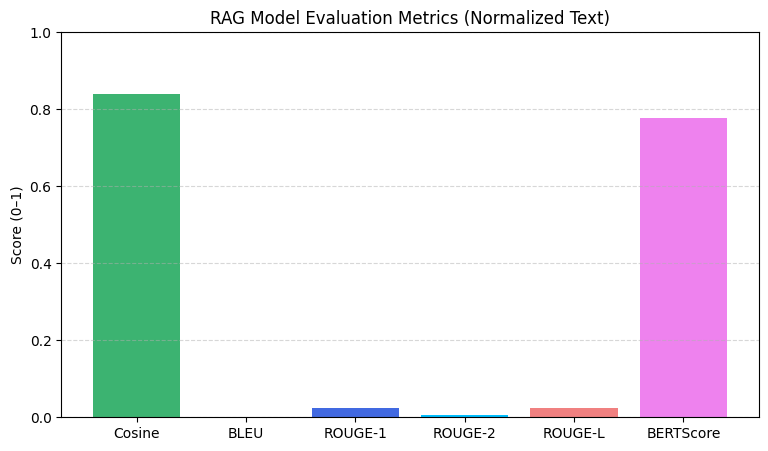

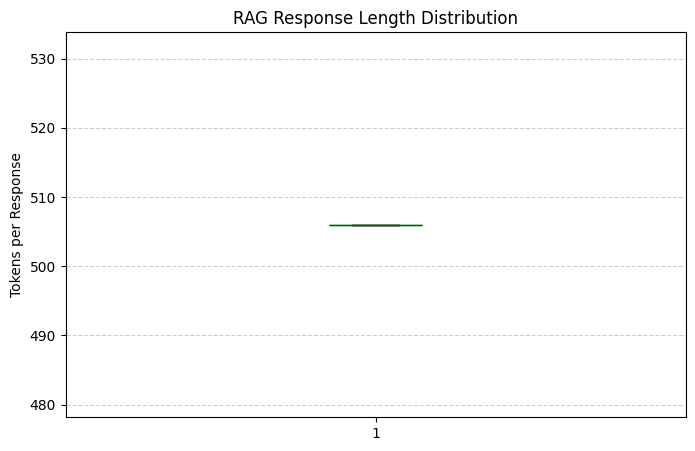


✅ Evaluation complete — normalized BLEU, ROUGE-1/2/L, cosine, and BERTScore metrics generated.


In [ ]:
from tabulate import tabulate
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
from evaluate import load
import pandas as pd
import torch, re

# --- Load metrics ---
bleu = load("bleu")
rouge = load("rouge")
bertscore = load("bertscore")

# --- Load embedding model ---
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# --- Text Normalization Helper ---
def normalize(text):
    """Normalize text for fairer BLEU/ROUGE scoring."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text)         # collapse spaces
    return text.strip()

# --- Cosine Similarity ---
def cosine_groundedness(answer, contexts):
    if not contexts:
        return 0.0
    context_text = " ".join(contexts)
    emb_answer = embedding_model.encode(answer, convert_to_tensor=True)
    emb_context = embedding_model.encode(context_text, convert_to_tensor=True)
    return float(util.cos_sim(emb_answer, emb_context))

# --- Stylistic Metrics ---
def response_length(text):
    return len(text.split())

def lexical_diversity(text):
    words = text.split()
    return len(set(words)) / len(words) if words else 0.0
def generate_finetuned_response(question, context=None):
    if context:
        prompt = f"""### Instruction:
Answer the question using the following context.

### Context:
{context}

### Guidance:
- Use phrasing and keywords similar to the context.
- Keep the answer concise and factual.

### Question:
{question}

### Response:"""
    else:
        prompt = f"""### Instruction:
{question}

### Guidance:
- Respond concisely.
- Use relevant technical or factual terms.

### Response:"""

    inputs = base_tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
    **inputs,
    num_beams=5,
    length_penalty=0.8,
    no_repeat_ngram_size=3,
    early_stopping=True,
    eos_token_id=base_tokenizer.eos_token_id,
    pad_token_id=base_tokenizer.pad_token_id
)
    response = base_tokenizer.decode(output[0], skip_special_tokens=True)
    response = response[len(prompt):].strip()
    return response

# === Main Evaluation Function ===
def run_comparison():
    results = []
    rag_cosine_scores, rag_bleu_scores = [], []
    rag_rouge1_scores, rag_rouge2_scores, rag_rougeL_scores = [], [], []
    rag_bert_scores, rag_lengths, rag_diversity = [], [], []

    print("\n--- Evaluating RAG-Specific & General Questions ---")

    general_questions = [
        "What is the capital of France?",
        "Tell me a fun fact about giraffes."
    ]
    rag_questions = [
        "Explain the main components of a transformer model in NLP.",
        "What is the significance of QLoRA in fine-tuning large language models?"
    ]

    for q in general_questions + rag_questions:
        base_res = generate_base_response(q)
        ft_res = generate_finetuned_response(q)
        rag_res, contexts, _, _ = rag_query_multihop(q)

        # --- Truncate long RAG responses ---
        rag_res = " ".join(rag_res.split()[:512])

        # --- Normalize all texts ---
        rag_res = normalize(rag_res)
        ft_res = normalize(ft_res)

        # --- 1️⃣ Cosine Similarity ---
        cos_score = cosine_groundedness(rag_res, contexts)
        rag_cosine_scores.append(cos_score)

        # --- 2️⃣ BLEU ---
        bleu_score = bleu.compute(predictions=[rag_res], references=[ft_res])["bleu"]
        rag_bleu_scores.append(bleu_score)

        # --- 3️⃣ ROUGE (1, 2, L) ---
        rouge_scores = rouge.compute(predictions=[rag_res], references=[ft_res])
        rag_rouge1_scores.append(rouge_scores["rouge1"])
        rag_rouge2_scores.append(rouge_scores["rouge2"])
        rag_rougeL_scores.append(rouge_scores["rougeL"])

        # --- 4️⃣ BERTScore ---
        bert_out = bertscore.compute(predictions=[rag_res], references=[ft_res], lang="en")
        bert_mean = float(np.mean(bert_out["f1"]))
        rag_bert_scores.append(bert_mean)

        # --- 5️⃣ Length & Diversity ---
        rag_lengths.append(response_length(rag_res))
        rag_diversity.append(lexical_diversity(rag_res))



        # --- Table Row ---
        results.append([q, "Base Model", base_res[:70] + "..."])
        results.append([q, "Fine-Tuned", ft_res[:70] + "..."])
        results.append([q, f"RAG (BLEU={bleu_score:.2f}, R1={rouge_scores['rouge1']:.2f}, R2={rouge_scores['rouge2']:.2f})", rag_res[:70]+"..."])

    # === Metrics Summary ===
    metrics = {
        "Avg Cosine Similarity": np.mean(rag_cosine_scores),
        "Avg BLEU Score": np.mean(rag_bleu_scores),
        "Avg ROUGE-1 Score": np.mean(rag_rouge1_scores),
        "Avg ROUGE-2 Score": np.mean(rag_rouge2_scores),
        "Avg ROUGE-L Score": np.mean(rag_rougeL_scores),
        "Avg BERTScore (F1)": np.mean(rag_bert_scores),
        "Avg RAG Response Length": np.mean(rag_lengths),
        "Avg RAG Lexical Diversity": np.mean(rag_diversity)
    }

    # === Print Tables ===
    print("\n" + tabulate(results, headers=["Question", "Model", "Response Snippet"],
                          tablefmt="fancy_grid", maxcolwidths=[40, 30, 70]))
    print("\n" + tabulate(metrics.items(), headers=["Metric", "Value"],
                          tablefmt="fancy_grid", floatfmt=".3f"))

    # === Visualization: Semantic/Textual Quality ===
    plt.figure(figsize=(9, 5))
    plt.bar(["Cosine", "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore"],
            [metrics["Avg Cosine Similarity"],
             metrics["Avg BLEU Score"],
             metrics["Avg ROUGE-1 Score"],
             metrics["Avg ROUGE-2 Score"],
             metrics["Avg ROUGE-L Score"],
             metrics["Avg BERTScore (F1)"]],
            color=["mediumseagreen", "steelblue", "royalblue", "deepskyblue", "lightcoral", "violet"])
    plt.title("RAG Model Evaluation Metrics (Normalized Text)")
    plt.ylabel("Score (0–1)")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # === Visualization: Length Distribution ===
    plt.figure(figsize=(8, 5))
    plt.boxplot(rag_lengths, patch_artist=True,
                boxprops=dict(facecolor="lightgreen", color="green"),
                medianprops=dict(color="darkgreen"))
    plt.title("RAG Response Length Distribution")
    plt.ylabel("Tokens per Response")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

    print("\n✅ Evaluation complete — normalized BLEU, ROUGE-1/2/L, cosine, and BERTScore metrics generated.")


# --- Run Evaluation ---
run_comparison()


In [ ]:
# --- Demo 1: Conversational Style (Testing Fine-Tuning) ---
print("\n--- DEMO 1: Conversational Style ---")
q1 = "I am feeling overwhelmed by my coursework. Can you give me some advice?"
r1, ctxs, subqs, trace = rag_query_multihop(q1, hops=2, k=8)
#r1, _ = rag_query(q1)
print(f"\n[USER] {q1}")
print("Sub-questions:", subqs)
print("Trace:", "\n".join(trace))
print(f"[ASSISTANT] {r1}")

# --- Demo 2: Knowledge Grounding (Testing RAG) ---
print("\n--- DEMO 2: Knowledge Grounding ---")
q2 = "According to the latest research, what is the significance of using a large dataset for training a new deep learning model?"
r2, ctxs, subqs, trace = rag_query_multihop(q2, hops=2, k=8)
#r2, contexts = rag_query(q2)
print(f"\n[USER] {q2}")
print("Sub-questions:", subqs)
print("Trace:", "\n".join(trace))
print(f"[ASSISTANT] {r2}")
print(f"\n[CONTEXTS RETRIEVED] {len(ctxs)} documents were used to answer this question.")

# --- Demo 3: Out-of-Context Question (Testing Groundedness) ---
print("\n--- DEMO 3: Out-of-Context Question ---")
q3 = "What is the capital of France?"
#r3, _ = rag_query(q3)
r3, ctxs, subqs, trace = rag_query_multihop(q3, hops=2, k=8)
print(f"\n[USER] {q3}")
print("Sub-questions:", subqs)
print("Trace:", "\n".join(trace))
print(f"[ASSISTANT] {r3}")


--- DEMO 1: Conversational Style ---

[USER] I am feeling overwhelmed by my coursework. Can you give me some advice?
Sub-questions: ['Break the following question into 2 short, logical sub-questions to answer sequentially:', 'Question: I am feeling overwhelmed by my coursework. Can you give me some advice?']
Trace: [Hop 1] Q: Break the following question into 2 short, logical sub-questions to answer sequentially:
Ctx:
  This paper considers the problem of reasoning on massive amounts of (possibly
distributed) data. Presently, existing proposals show some limitations: {\em
(i)} the quantity of data that can be handled contemporarily is limited, due to
the fact that reasoning is generally carried out in main-memory; {\em (ii)} the
interaction with external (and independent) DBMSs is not trivial and, in
several cases, not allowed at all; {\em (iii)} the efficiency of present
implementations is still not sufficie
[Hop 2] Q: You are solving a multi-hop question.
Ctx:
  A free zero-range pr

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import time

def chat_with_rag_iterative(message, history):
    """
    Function to be used by Gradio's ChatInterface. Calls rag_query and returns the response.
    The `history` parameter allows the ChatInterface to display past turns.
    For this implementation, the `rag_query` still processes the current `message` for retrieval.
    """
    start_time = time.time()
    response, contexts = rag_query(message)
    end_time = time.time()
    inference_time = end_time - start_time

    # Append inference time to the response
    response_with_time = f"{response}\n\n(Inference time: {inference_time:.2f} seconds)"

    # Append references if available
    if contexts:
        references_text = "\n\n---\n**References:**\n"
        for i, context in enumerate(contexts):
            references_text += f"{i+1}. {context[:200]}...\n" # Show first 200 chars of each context
        response_with_time += references_text

    return response_with_time

# Create the Gradio ChatInterface for iterative conversation
iface = gr.ChatInterface(
    fn=chat_with_rag_iterative,
    title="RAG Chatbot with Conversational Memory",
    description="Chat with the RAG-powered model. It uses an arXiv abstracts knowledge base and remembers conversation history."
)

# Launch the interface
print("Launching Gradio interface...")
iface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d5c8a8619776f5e4d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
